<a href="https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/extras/Womersley_Flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LEARNING OBJECTIVE

This notebook illustrates Womersley's classic complex-variables solution for time-periodic unidirectional flow in a 3D axisymmetric tube and in a 2D slot using interactive plots and movies. The flow rate and wall shear stress are computed using symbolic manipulations and plotted as functions of the dimensionless Womersley number. The pressure-flow phasing is highlighted.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

from matplotlib import animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline

import numpy as np
import scipy.special as sps

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org) &amp; [Shrihari D. Pande](https://scholar.google.com/citations?user=F89WfXYAAAAJ&hl=en), Purdue University.

# Womersley flow in an axisymmetric tube

## The axial flow profile

The velocity profile for unidirectional flow, $\underline{v} = v_z(r,t)\underline{e}_z$, in axisymmetric cylindrical coordinates, driven by an axial pressure gradient, $-dp/dz$, obeys
$$
    \rho \frac{\partial v_z}{\partial t} = \mu \frac{1}{r}\frac{\partial}{\partial r}\left(r\frac{\partial v_z}{\partial r}\right) - \frac{d p}{d z},\qquad 
    |v_z(0,t)|<\infty,\quad v_z(a,t) = 0.
$$
Considering only post-transient (periodic) oscillations and introducing [_phasors_](https://en.wikipedia.org/wiki/Phasor), 
$$
    v_z(r,t) = \Re[g(r)e^{\mathrm{i}\omega t}],\qquad 
    -\frac{dp}{dz} = \Re\{G e^{\mathrm{i}\omega t}\}, 
$$
the problem becomes
$$
    \rho \, \mathrm{i} \, \omega g(r) = \mu \frac{1}{r}\left(r g'(r)\right)' + G,\qquad |g(0)|<\infty, \quad g(a)=0,
$$
or
$$
    g''(r) + \frac{1}{r} g'(r) - \frac{\mathrm{i} \omega \rho}{\mu} g(r) = -\frac{G}{\mu},\qquad |g(0)|<\infty, \quad g(a)=0,
$$
This is a type of _inhomogeneous_ [Bessel equation](https://en.wikipedia.org/wiki/Bessel_function), which we can also solve with [SymPy](https://docs.sympy.org/latest/tutorial/index.html).

Some further details of this derivation can be found in [textbooks](https://www.sciencedirect.com/science/chapter/edited-volume/abs/pii/B9780123821003100162), and more recently in [our work](https://arxiv.org/abs/2304.00543).

general solution:


apply BC at r = 0:


solve for remaining constant of intergration:


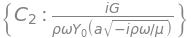

apply BC at r = a:


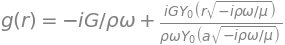

In [2]:
# define symbols
ρ, μ, ω, r, a, G = sp.symbols('ρ μ ω r a G', real=True)
g = sp.Function('g')

# solve the homogeneous part
ode_h = sp.Eq(g(r).diff(r, 2) + (1/r)*g(r).diff(r) - sp.I*ρ*ω/μ*g(r), 0)
sol_h = sp.dsolve(ode_h, g(r))

# guess for the particular solution (constant)
A = G/(sp.I*ρ*ω)

# find the general solution
sol = sp.Eq(g(r), sol_h.rhs + A)
print('general solution:')
display(sol)

# Bessel Y_0 blows up at r = 0, so set C2 = 0:
params = {ρ, μ, ω, r, a, G}
# separate the constants of integration from the other symbols
consts = [s for s in sol.free_symbols - params if s.name.startswith('C')]
sol = sp.Eq(g(r), sol.rhs.subs({consts[0]: 0}))
print('apply BC at r = 0:')
display(sol)

# apply no BC slip at r = a to find C1:
bc_eqs = [sp.Eq(sol.rhs.subs(r,a),0)]
bc_sol= sp.solve(bc_eqs, consts[1])
print('solve for remaining constant of intergration:')
display(bc_sol)
sol = sp.Eq(g(r), sol.rhs.subs(bc_sol).simplify())
print('apply BC at r = a:')
display(sol)


Thus, the oscillatory flow profile is:
$$
  v_z(r,t) = \Re\left\{\frac{G a^2}{\mu} \frac{1}{\mathrm{i} \alpha^2}\left[1-\frac{J_0(\mathrm{i}^{3/2}\alpha\space r/a)}{J_0(\mathrm{i}^{3/2}\alpha)}\right]e^{\mathrm{i}\omega t}\right\},
$$
where $\alpha=a \sqrt{\rho \omega/\mu}$ is the _Womersley number_, $G = \Delta p/\ell$ is the equivalent steady gradient, and $a$ is the tube radius.

To make the profile dimensionless, we use the following variables:
$$
  R=\frac{r}{a},\quad Z=\frac{z}{\ell},\quad T=\frac{\omega t}{2 \pi},\quad V_Z=\frac{v_z}{\mathcal{V}_z},
$$
where $\mathcal{V}_z = a^2 G/\mu = a^2 \Delta p/(\mu \ell)$ is the axial velocity _scale_,
to obtain
$$
  V_Z(R,T)=\Re\left\{\frac{1}{\mathrm{i} \alpha^2}\left[1-\frac{J_0(\mathrm{i}^{3/2}\alpha R)}{J_0(\mathrm{i}^{3/2}\alpha)}\right]e^{\mathrm{i} 2\pi T}\right\}.
$$

In [3]:
# refresh symbols
α, R, T = sp.symbols('α R T', real=True)
# the spatial variation of V_Z, 
# NOTE: G is dimensionless g, not the pressure grad
G = 1/(sp.I * α**2) * ( 1 - sp.besselj(0,sp.I**sp.Rational(3,2)*α*R) \
                            / sp.besselj(0,sp.I**sp.Rational(3,2)*α) )

In [4]:
# check that G function we defined solves the dimensionless ODE:
sp.simplify(sp.Eq(sp.I*α**2*G, (1/R)*(R*G.diff(R)).diff(R) + 1))

[`lambdify`](https://docs.sympy.org/latest/modules/utilities/lambdify.html) the velocity profile function for evaluation and plotting.

In [5]:
Womersley = sp.lambdify([R, α, T], sp.re(G*sp.exp(sp.I*sp.pi*T*2)), 'scipy')

### Interactive plot

In [ ]:
def plot_func(α, T=0, frz_xlim=False):
  Rp = np.linspace(-1, 1, 1000)
  V_z = Womersley(Rp, α, T)

  #plt.figure(2)
  fig, ax = plt.subplots(tight_layout=True)

  # skip every nth data point to reduce number of arrows
  # plot arrows emanating only from the reference line, x-coord = 0
  ax.quiver(0*Rp[::30], Rp[::30],
            V_z[::30], 0*V_z[::30],
            scale=1., scale_units='xy', color='skyblue', zorder=2)
  ax.plot(V_z, Rp, color='royalblue', linewidth=4, label=rf'$\alpha={α:.2f}$')
  
  ax.set_ylabel('$R$')
  ax.set_ylim(-1,1)
  ax.set_xlabel('$V_Z$')
  #ax.set_xlim(min(V_z)-0.1, max(V_z)+0.1)
  if frz_xlim:
    ax.set_xlim(-0.5, 0.5)

  ax.xaxis.set_major_locator(plt.MaxNLocator(4))
  #ax.yaxis.set_major_locator(plt.MaxNLocator(4))

  # fix the issue of having negative R values on the plot
  ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
  ax.set_yticklabels(['1.0', '0.5', '0.0', '0.5', '1.0']) 
  
  ax.legend()

  ax.grid(alpha=0.5, linestyle='dotted')

  plt.show()

First, a static plot.

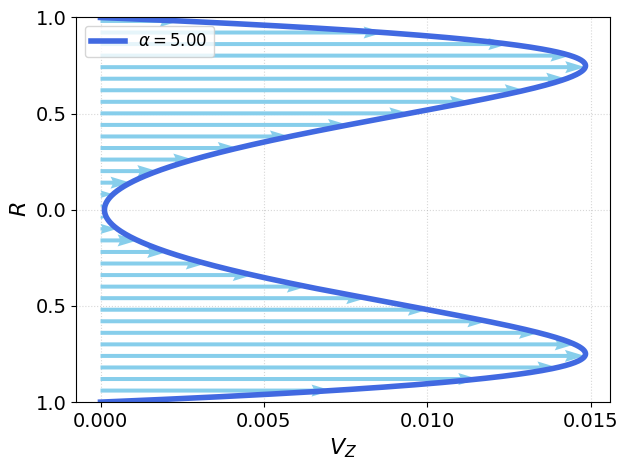

In [7]:
plot_func(5)
# if you want to save the thumbnail to a file
#fig.savefig("Wo_0.5_thumb.pdf") # bbox_inches='tight'

Then, an [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $\alpha$ and $T$. A checkbox allows us to lock the horizontal axis, to prevent it from auto-scaling, which is useful when varying $T$.

In [ ]:
interact(plot_func, α = widgets.FloatSlider(value=1, min=0.1, max=20, step=0.1),
                    T = widgets.FloatSlider(min=0, max=2, step=0.05),
                    frz_xlim = widgets.Checkbox(value=True, description='Freeze xlim?') );

interactive(children=(FloatSlider(value=1.0, description='α', max=20.0, min=0.1), FloatSlider(value=0.0, descr…

### Animation

We start by making a thumbnail picture/initial plot (also useful when including into a $\LaTeX$ presentation). Then, we animate it.

In [55]:
my_α = 5
Rp = np.linspace(-1, 1, 1000, endpoint=True)
V_z = Womersley(Rp, my_α, 0)

fig, ax = plt.subplots(tight_layout=True)

# skip every nth data point to reduce number of arrows
# plot arrows emanating only from the reference line, x-coord = 0
quiv = ax.quiver(0*Rp[::30], Rp[::30],
                 V_z[::30], 0*V_z[::30],
                 scale=1., scale_units='xy', color='skyblue', zorder=2)
line, = ax.plot(V_z, Rp, color='royalblue', linewidth=4, label=rf'$\alpha={my_α:.2f}$')

ax.set_ylabel('$R$')
ax.set_ylim(-1,1)
ax.set_xlabel('$V_Z$')
#ax.set_xlim(min(V_z)-0.1,max(V_z)+0.1)
ax.set_xlim(-0.3,0.3)

ax.xaxis.set_major_locator(plt.MaxNLocator(4))
#ax.yaxis.set_major_locator(plt.MaxNLocator(4))

# fix the issue of having negative R values on the plot
ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax.set_yticklabels(['1.0', '0.5', '0.0', '0.5', '1.0']) 

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

# if you want to save the thumbnail to a file
#fig.savefig("Wo_0.5_thumb.pdf") # bbox_inches='tight'

plt.close()

def animate(i):
  V_z = Womersley(Rp,my_α,i/100)

  # update the plot data
  quiv.set_UVC(V_z[::30], 0*V_z[::30])
  line.set_xdata(V_z)

  return line, quiv,

ani = animation.FuncAnimation(fig, animate,
                              interval=20, blit=True, save_count=1000)

In [ ]:
# Note: below is the part which makes it work on Colab
rc('animation', html='jshtml')
ani

In [11]:
# To save the animation, use e.g.
#ani.save("Wo_5_movie.mp4")

# or
#writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)
#ani.save("movie.mp4", writer=writer)

## The flow rate

The dimensionless flow rate is $Q = \int_0^{2\pi}\int_0^1 V_Z(R) \, RdRd\theta$, it's amplitude (time-independent) is then  $2\pi \int_0^1 G(R) \, RdR$.

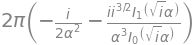

In [12]:
# the amplitude of the flow rate oscillations
Q = 2*sp.pi*sp.integrate(G*R,(R,0,1),conds='none').simplify()
Q

In [13]:
# since general besseli expansions might not be defined in SymPy
# https://en.wikipedia.org/wiki/Bessel_function#Modified_Bessel_functions:_I%CE%B1,_K%CE%B1
z = sp.sqrt(sp.I)*α
I0_series = 1 + z**2/4 + z**4/64
I1_series = z/2 + z**3/16 + z**5/384

Q_sub = Q.subs(R, 1).subs(sp.besseli(0, z), I0_series).subs(sp.besseli(1, z), I1_series)
Q_zero = sp.series(Q_sub, α, 0, 4)
print('α << 1 expansion of the flow rate amplitude:')
Q_zero

α << 1 expansion of the flow rate amplitude:


The $\pi/8$ is from steady Hagen&ndash;Poiseuille flow. The other term is the first correction due to flow oscillations.

α >> 1 expansion of the flow rate amplitude:


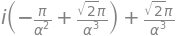

In [14]:
# since general besseli expansions might not be defined in SymPy
# using Mathematica, and neglecting exponentially small terms
z = sp.sqrt(sp.I)*α
I0_series = (sp.exp(z)*(9+16*z+128*z**2))/(128*sp.sqrt(2*sp.pi)*z**(5/2))
I1_series = (sp.exp(z)*(-15-48*z+128*z**2))/(128*sp.sqrt(2*sp.pi)*z**(5/2))

Q_sub = Q.subs(R, 1).subs(sp.besseli(0, z), I0_series).subs(sp.besseli(1, z), I1_series)
Q_inf = sp.series(Q_sub, α, sp.oo, 4)
print('α >> 1 expansion of the flow rate amplitude:')
# expand_complex to readably separate real and imag parts:
sp.expand_complex(Q_inf.removeO())

In [15]:
flowrate      = sp.lambdify([α, T], Q*sp.exp(sp.I*sp.pi*T*2), 'scipy')
flowrate_zero = sp.lambdify([α, T], Q_zero.removeO()*sp.exp(sp.I*sp.pi*T*2), 'scipy')
flowrate_inf  = sp.lambdify([α, T], Q_inf.removeO()*sp.exp(sp.I*sp.pi*T*2), 'scipy')

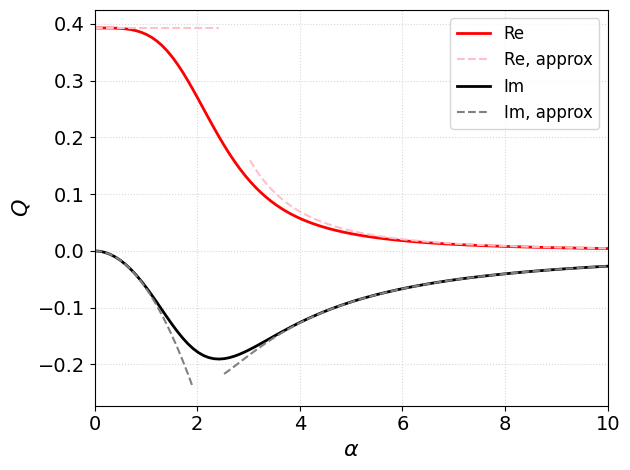

In [16]:
my_αs = np.linspace(1e-4, 10, 100)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(my_αs, flowrate(my_αs,0).real, linewidth=2, color='red', label='Re')
ax.plot(my_αs[0:25], flowrate_zero(my_αs[0:25],0).real, 
        linewidth=1.5, color='pink', linestyle='dashed', label=r'Re, approx')
ax.plot(my_αs[30:100], flowrate_inf(my_αs[30:100],0).real, 
        linewidth=1.5, color='pink', linestyle='dashed')
ax.plot(my_αs, flowrate(my_αs,0).imag, linewidth=2, color='black', label='Im')
ax.plot(my_αs[0:20], flowrate_zero(my_αs[0:20],0).imag, 
        linewidth=1.5, color='gray', linestyle='dashed', label=r'Im, approx')
ax.plot(my_αs[25:100], flowrate_inf(my_αs[25:100],0).imag, 
        linewidth=1.5, color='gray', linestyle='dashed')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('$Q$')

ax.set_xlim(0, my_αs.max())
#ax.set_ylim()

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

## Phasing between the flow rate and pressure drop

Since the flow is unidirectional, the pressure gradient is constant, $-dp/dz = G = \Delta p/\ell$, we may use "pressure gradient" and "pressure drop" interchangeably.

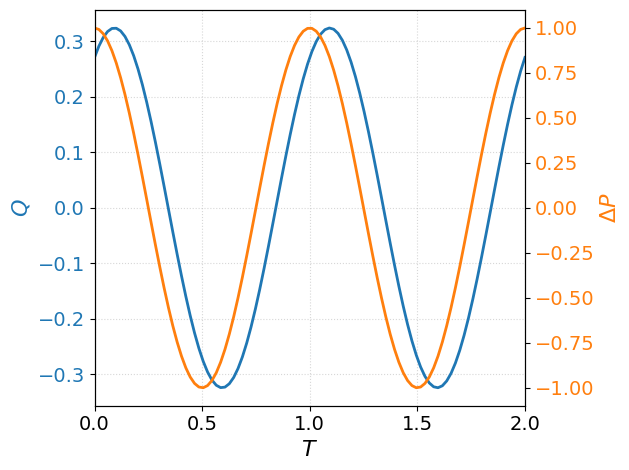

In [ ]:
my_alpha = 2

my_Ts = np.linspace(0, 2, 100)

q_plot = flowrate(my_alpha,my_Ts).real
#q_plot = q_plot/q_plot.max()
dp_plot = (np.exp(1j*np.pi*my_Ts*2)).real

fig, ax1 = plt.subplots(tight_layout=True)

ax1.plot(my_Ts, q_plot, linewidth=2, color='tab:blue') #label=r'$Q/Q_\mathrm{max}$'

ax1.set_xlabel(r'$T$')
ax1.set_xlim(my_Ts.min(), my_Ts.max())
#ax1.set_ylim()
ax1.set_ylabel(r'$Q$', color='tab:blue')  # we already handled the x-label with ax1
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.grid(alpha=0.5, linestyle='dotted')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel(r'$\Delta P$', color='tab:orange')
ax2.plot(my_Ts, dp_plot, linewidth=2, color='tab:orange') #label=r'$\Delta P$'
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax.legend();

Clearly, there is a phase shift between $Q$ and $\Delta P$. $Q$ _lags behind_ $\Delta P$ because it reaches its maximum at a _later_ $T$. This is generated by the comples value function $2\pi \int_0^1 G(R)\, RdR$. We can plot this function's [argument](https://en.wikipedia.org/wiki/Argument_(complex_analysis)), using [`angle`](https://numpy.org/devdocs/reference/generated/numpy.angle.html),  versus the Womersley number $\alpha$.

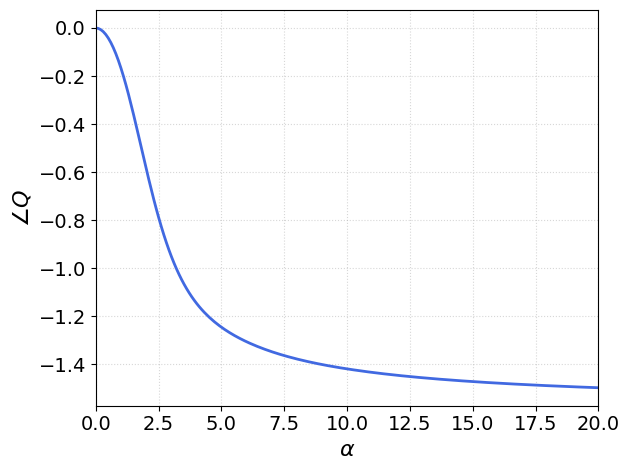

In [ ]:
my_αs = np.linspace(1e-4, 20, 200)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(my_αs, np.angle(flowrate(my_αs,0)), color='royalblue', 
        linewidth=2)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\angle Q$')

ax.set_xlim(0, my_αs.max())
#ax.set_ylim(0, 0.6)

ax.grid(alpha=0.5, linestyle='dotted');

As the Womersley number increases, so does the flow rate lag/phase shift.

## The wall shear stress

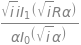

In [19]:
# the amplitude of the shear stress oscillations
Gp = G.diff(R)
Gp

In [20]:
sstress = sp.lambdify([R, α, T], Gp*sp.exp(sp.I*sp.pi*T*2), 'scipy')

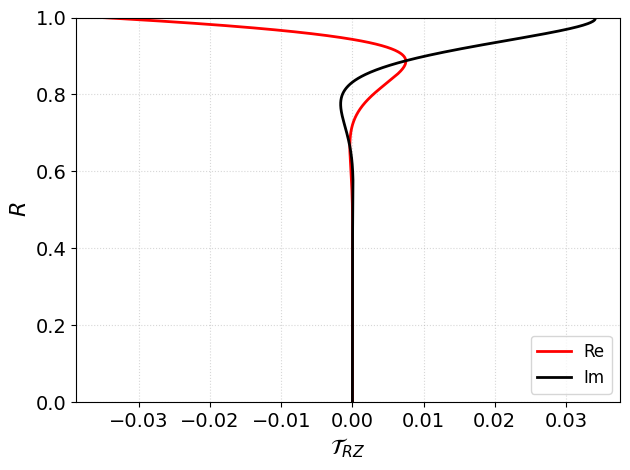

In [ ]:
my_alpha = 20

my_R = np.linspace(0, 1, 1000, endpoint=True)
ssa = sstress(my_R, my_alpha, 0)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(ssa.real, my_R, linewidth=2, label='Re', color='red')
ax.plot(ssa.imag, my_R, linewidth=2, label='Im', color='black')

ax.set_ylabel('$R$')
ax.set_xlabel(r'$\mathcal{T}_{RZ}$')

ax.set_ylim(0, 1)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3, 3)) 

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend(loc='lower right');

### Limiting behaviors

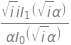

In [22]:
Gp.subs(R,1).simplify()

In [23]:
# since general besseli expansions might not be defined in SymPy
# https://en.wikipedia.org/wiki/Bessel_function#Modified_Bessel_functions:_I%CE%B1,_K%CE%B1
z = sp.sqrt(sp.I)*α
I0_series = 1 + z**2/4 + z**4/64
I1_series = z/2 + z**3/16 + z**5/384

Gp_sub = Gp.subs(R, 1).subs(sp.besseli(0, z), I0_series).subs(sp.besseli(1, z), I1_series)
Gp_zero = sp.series(Gp_sub, α, 0, 6).powsimp(force=True)
print('α << 1 expansion of shear stress at R = 1:')
Gp_zero

α << 1 expansion of shear stress at R = 1:


α >> 1 expansion of shear stress at R = 1:


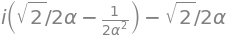

In [24]:
# since general besseli expansions might not be defined in SymPy
# using Mathematica, and neglecting exponentially small terms
z = sp.sqrt(sp.I)*α
I0_series = (sp.exp(z)*(9+16*z+128*z**2))/(128*sp.sqrt(2*sp.pi)*z**(5/2))
I1_series = (sp.exp(z)*(-15-48*z+128*z**2))/(128*sp.sqrt(2*sp.pi)*z**(5/2))

Gp_sub = Gp.subs(R, 1).subs(sp.besseli(0, z), I0_series).subs(sp.besseli(1, z), I1_series)
Gp_inf = sp.series(Gp_sub, α, sp.oo, 3)
print('α >> 1 expansion of shear stress at R = 1:')
# expand_complex to readably separate real and imag parts:
sp.expand_complex(Gp_inf.removeO())

In [25]:
wss      = sp.lambdify([α, T], Gp.subs(R,1)*sp.exp(sp.I*sp.pi*T*2), 'scipy')
wss_zero = sp.lambdify([α, T], Gp_zero.removeO()*sp.exp(sp.I*sp.pi*T*2), 'scipy')
wss_inf  = sp.lambdify([α, T], Gp_inf.removeO()*sp.exp(sp.I*sp.pi*T*2), 'scipy')

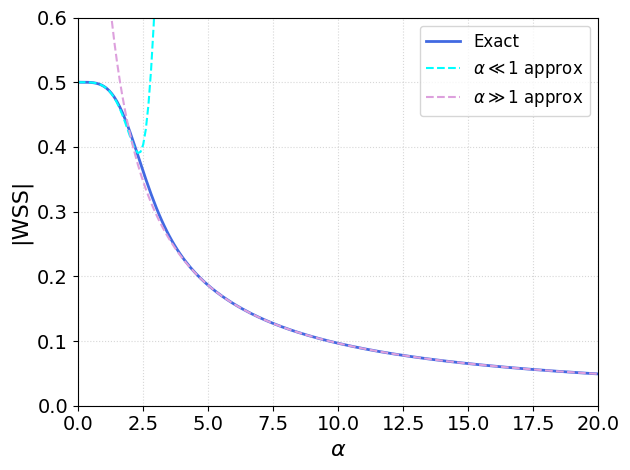

In [ ]:
my_αs = np.linspace(1e-4, 20, 200)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(my_αs, abs(wss(my_αs, 0)), color='royalblue', 
        linewidth=2, label='Exact')
ax.plot(my_αs, abs(wss_zero(my_αs, 0)), color='cyan', 
        linestyle='dashed', linewidth=1.5, label=r'$\alpha\ll1$ approx')
ax.plot(my_αs, abs(wss_inf(my_αs, 0)), color='plum', 
        linestyle='dashed', linewidth=1.5, label=r'$\alpha\gg1$ approx')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('|WSS|')

ax.set_xlim(0, my_αs.max())
ax.set_ylim(0, 0.6)

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

# Womersley flow in a slot

A slot is a 2D channel with rigid parallel walls that extend infinitely out of the page.

## The axial flow profile


The velocity profile for unidirectional flow, $\underline{v} = v_z(y,t)\underline{e}_z$, in 2D Cartesian coordinates, driven by an oscillatory axial pressure gradient, $-dp/dz$, obeys
$$
  \rho\frac{\partial v_z}{\partial t} = \mu\frac{\partial^2 v_z}{\partial y^2} - \frac{d p}{d z},\qquad
  v_z(0,t)=v_z(h,t) = 0.
$$
Considering only post-transient (periodic) oscillations and introducing [_phasors_](https://en.wikipedia.org/wiki/Phasor), 
$$
  v_z(r,t) = \Re[f(y)e^{\mathrm{i}\omega t}],\qquad
  -\frac{dp}{dz} = \Re\{G e^{\mathrm{i}\omega t}\},
$$
the problem becomes
$$
  \rho \, \mathrm{i} \, \omega f(y) = \mu f''(y) + G,\qquad f(0)=f(h)=0.
$$
This ODE is straightforward to solve with [SymPy](https://docs.sympy.org/latest/tutorial/index.html).

Some further details of this derivation can be found in [textbooks](https://www.sciencedirect.com/science/chapter/monograph/pii/B9780080339337500106), and more recently in [our work](https://arxiv.org/abs/2304.00543).

general solution:


solve for constants of intergration::


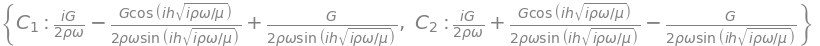

apply BCs to solution:


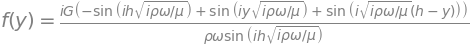

In [27]:
# Symbols
ρ, μ, ω, y, h, G = sp.symbols('ρ μ ω y h G', real=True)
f = sp.Function('f')

# General solution
sol = sp.dsolve(sp.Eq(ρ*sp.I*ω*f(y), μ*f(y).diff(y,2) + G), f(y)).rewrite(sp.cos)
print('general solution:')
display(sol)

# No slip at y=0,h:
params = {ρ, μ, ω, y, h, G}
consts = [s for s in sol.free_symbols - params if s.name.startswith('C')]
bc_eqs = [sp.Eq(sol.rhs.subs(y,0),0), sp.Eq(sol.rhs.subs(y,h),0)]
bc_sol = sp.solve(bc_eqs, consts)
print('solve for constants of intergration::')
display(bc_sol)
sol = sp.Eq(f(y), sol.rhs.subs(bc_sol).simplify())
print('apply BCs to solution:')
display(sol)


Thus, the oscillatory flow profile is:
$$
  v_z(y,t) = \Re\left\{\frac{G h^2}{\mu} \frac{1}{\mathrm{i} α^2}\left[1-\frac{\cos(\mathrm{i}^{3/2}\alpha (1-2y/h)/2)}{\cos(\mathrm{i}^{3/2}\alpha/2)}\right]e^{\mathrm{i}\omega t}\right\},
$$
where $\alpha=h_0 \sqrt{\rho \omega/\mu}$ is the _Womersley number_, $G = \Delta p/\ell$ is the equivalent steady gradient, and $h$ is the channel height.

To make the profile dimensionless, we use the following variables:
$$
  Y=\frac{y}{h},\quad Z=\frac{z}{\ell},\quad T=\frac{\omega t}{2 \pi},\quad V_Z=\frac{v_z}{\mathcal{V}_z},
$$
where $\mathcal{V}_z = h^2 G/\mu = h^2 \Delta p/(\mu \ell)$ is the axial velocity _scale_,
to obtain
$$
  V_Z(Y,T) = \Re\left\{\frac{1}{\mathrm{i} α^2}\left[1-\frac{\cos\big(\mathrm{i}^{3/2}\alpha (1-2Y)/2\big)}{\cos\big(\mathrm{i}^{3/2}\alpha/2\big)}\right]e^{\mathrm{i} 2\pi T}\right\}.
$$

In [28]:
α, Y, T = sp.symbols('α Y T', real=True)
F = 1/(sp.I * α**2) * ( 1 - sp.cos(sp.I**sp.Rational(3,2)*α*(1-2*Y)*sp.Rational(1,2)) \
                              / sp.cos(sp.I**sp.Rational(3,2)*α*sp.Rational(1,2)) )

In [29]:
# check that it solves the dimensionless ODE:
sp.simplify(sp.Eq(sp.I*α**2*F, F.diff(Y,2) + 1))

In [30]:
Womersley2D = sp.lambdify([Y, α, T], sp.re(F*sp.exp(sp.I*sp.pi*T*2)), 'scipy')

### Interactive plot

In [ ]:
def plot_func(α, T=0, frz_xlim=False):
  Y = np.linspace(0, 1, 1000)
  V_z = Womersley2D(Y, α, T)

  fig, ax = plt.subplots(tight_layout=True)

  # skip every nth data point to reduce number of arrows
  # plot arrows emanating only from the reference line, x-coord = 0
  ax.quiver(0*Y[::30], Y[::30],
            V_z[::30], 0*V_z[::30],
            scale=1., scale_units='xy', color='skyblue', zorder=2)
  ax.plot(V_z, Y, color='royalblue', linewidth=4, label=fr'$\alpha={α:.2f}$')
  
  ax.set_ylabel('$Y$')
  ax.set_ylim(0, 1)
  ax.set_xlabel('$V_Z$')
  #ax.set_xlim(min(V_z)-0.1,max(V_z)+0.1)
  if frz_xlim:
    ax.set_xlim(-0.15, 0.15)

  ax.xaxis.set_major_locator(plt.MaxNLocator(4))
  ax.yaxis.set_major_locator(plt.MaxNLocator(4))

  ax.grid(alpha=0.5, linestyle='dotted')

  ax.legend()

  plt.show()

First, a static plot.

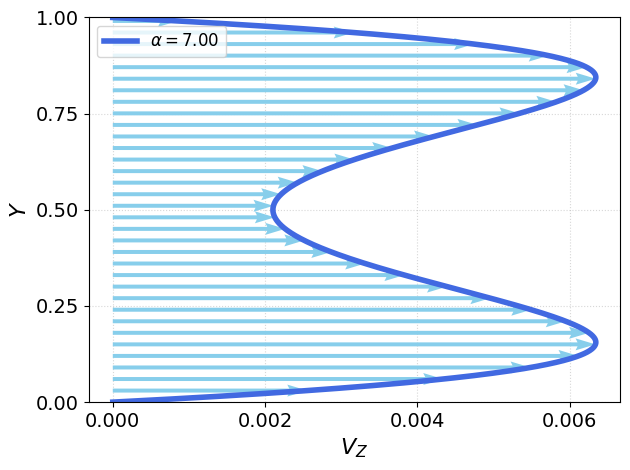

In [32]:
plot_func(7)

Then, an [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $\alpha$ and $T$. A checkbox allows us to lock the horizontal axis, to prevent it from auto-scaling, which is useful when varying $T$.

In [ ]:
interact(plot_func, α = widgets.FloatSlider(value=1, min=0.1, max=20, step=0.1),
                    T = widgets.FloatSlider(min=0, max=2, step=0.05),
                    frz_xlim = widgets.Checkbox(value=True, description='Freeze xlim?') );

interactive(children=(FloatSlider(value=1.0, description='α', max=20.0, min=0.1), FloatSlider(value=0.0, descr…

## The flow rate

The dimensionless flow rate is $Q = \int_0^1 V_Z(Y) \, dY$, it's amplitude (time-independent) is then  $\int_0^1 F(Y) \, dY$.

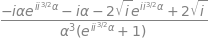

In [34]:
# the amplitude of the flow rate oscillations
# requires conds='none' because of the complex-valued integrand
Q2D = sp.integrate(F,(Y,0,1),conds='none').simplify()
Q2D

In [35]:
Q2D_zero = sp.series(Q2D, α, 0, 4)
print('α << 1 expansion of flow rate amplitude:')
sp.expand_complex(Q2D_zero.removeO())

α << 1 expansion of flow rate amplitude:


The $1/12$ is from steady Hagen&ndash;Poiseuille flow. The other term is the first correction due to flow oscillations. It is easier to get and understand this correction via the [reciprocal theorem](https://arxiv.org/abs/2312.10183).

α >> 1 expansion of the flow rate amplitude:


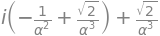

In [36]:
# manually eliminate the tan->tanh term, which is bounded at infinity
Q2D_inf = Q2D.rewrite(sp.tanh).simplify().subs(sp.tanh(sp.sqrt(sp.I)*α/2), 1)
Q2D_inf = sp.series(Q2D_inf, α, sp.oo, 4)
print('α >> 1 expansion of the flow rate amplitude:')
# expand_complex to readably separate real and imag parts:
sp.expand_complex(Q2D_inf.removeO())

In [37]:
flowrate2D      = sp.lambdify([α, T], Q2D*sp.exp(sp.I*sp.pi*T*2), 'scipy')
flowrate2D_zero = sp.lambdify([α, T], Q2D_zero.removeO()*sp.exp(sp.I*sp.pi*T*2), 'scipy')
flowrate2D_inf  = sp.lambdify([α, T], Q2D_inf.removeO()*sp.exp(sp.I*sp.pi*T*2), 'scipy')

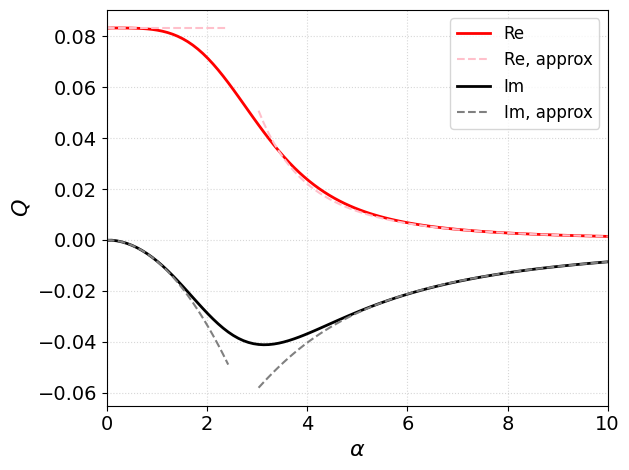

In [38]:
my_αs = np.linspace(1e-4, 10, 100)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(my_αs, flowrate2D(my_αs,0).real, linewidth=2, color='red', label='Re')
ax.plot(my_αs[0:25], flowrate2D_zero(my_αs[0:25],0).real, 
        linewidth=1.5, color='pink', linestyle='dashed', label=r'Re, approx')
ax.plot(my_αs[30:100], flowrate2D_inf(my_αs[30:100],0).real, 
        linewidth=1.5, color='pink', linestyle='dashed')
ax.plot(my_αs, flowrate2D(my_αs,0).imag, linewidth=2, color='black', label='Im')
ax.plot(my_αs[0:25], flowrate2D_zero(my_αs[0:25],0).imag, 
        linewidth=1.5, color='gray', linestyle='dashed', label=r'Im, approx')
ax.plot(my_αs[30:100], flowrate2D_inf(my_αs[30:100],0).imag, 
        linewidth=1.5, color='gray', linestyle='dashed')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('$Q$')

ax.set_xlim(0, my_αs.max())
#ax.set_ylim()

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

## Phasing between the flow rate and pressure gradient

Since the flow is unidirectional, the pressure gradient is constant, $-dp/dz = G = \Delta p/\ell$, we may use "pressure gradient" and "pressure drop" interchangeably.

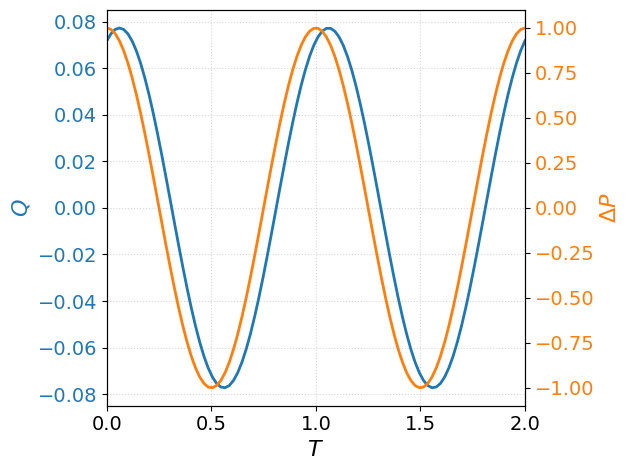

In [ ]:
my_alpha = 2

my_Ts = np.linspace(0, 2, 100)

q_plot = flowrate2D(my_alpha,my_Ts).real
#q_plot = q_plot/q_plot.max()
dp_plot = (np.exp(1j*np.pi*my_Ts*2)).real

fig, ax1 = plt.subplots(tight_layout=True)

ax1.plot(my_Ts, q_plot, linewidth=2, color='tab:blue') #label=r'$Q/Q_\mathrm{max}$'

ax1.set_xlabel(r'$T$')
ax1.set_xlim(my_Ts.min(), my_Ts.max())
#ax1.set_ylim()
ax1.set_ylabel(r'$Q$', color='tab:blue')  # we already handled the x-label with ax1
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.grid(alpha=0.5, linestyle='dotted')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel(r'$\Delta P$', color='tab:orange')
ax2.plot(my_Ts, dp_plot, linewidth=2, color='tab:orange') #label=r'$\Delta P$'
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax.legend();

Clearly, there is a phase shift between $Q$ and $\Delta P$. $Q$ _lags behind_ $\Delta P$ because it reaches its maximum at a _later_ $T$. This is generated by the comples value function $\int_0^1 F(Y)\, dY$. We can plot this function's [argument](https://en.wikipedia.org/wiki/Argument_(complex_analysis)), using [`angle`](https://numpy.org/devdocs/reference/generated/numpy.angle.html),  versus the Womersley number $\alpha$.

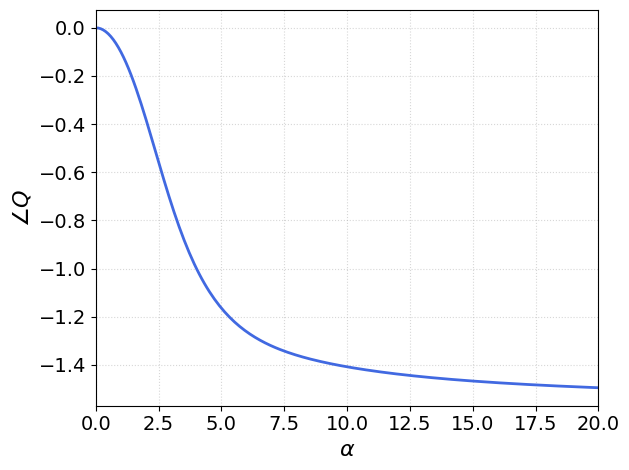

In [ ]:
my_αs = np.linspace(1e-4, 20, 200)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(my_αs, np.angle(flowrate2D(my_αs,0)), color='royalblue', 
        linewidth=2)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\angle Q$')

ax.set_xlim(0, my_αs.max())
#ax.set_ylim(0, 0.6)

ax.grid(alpha=0.5, linestyle='dotted');

As the Womersley number increases, so does the flow rate lag/phase shift.

## The wall shear stress

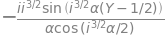

In [41]:
# the amplitude of the shear stress oscillations
Fp = F.diff(Y)
Fp.simplify()

In [42]:
sstress2D = sp.lambdify([Y, α, T], Fp*sp.exp(sp.I*sp.pi*T*2), 'scipy')

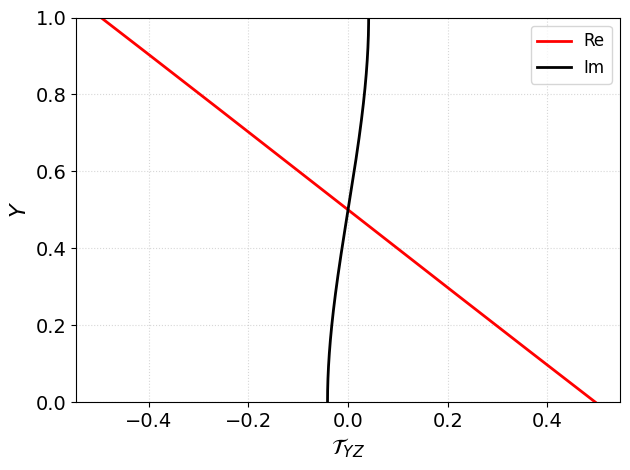

In [ ]:
my_alpha = 1

my_Y = np.linspace(0, 1, 1000, endpoint=True)
ssa2D = sstress2D(my_Y,my_alpha,0)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(ssa2D.real, my_Y, linewidth=2, label='Re', color='red')
ax.plot(ssa2D.imag, my_Y, linewidth=2, label='Im', color='black')

ax.set_ylabel('$Y$')
ax.set_xlabel(r'$\mathcal{T}_{YZ}$')

ax.set_ylim(0, 1)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3, 3))

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

### Limiting behaviors

In [44]:
Fp.subs(Y,1).simplify()

In [45]:
Fp_zero = sp.series(Fp.subs(Y,1), α, 0, 6)
print('α << 1 expansion of shear stress at Y = 1:')
Fp_zero


α << 1 expansion of shear stress at Y = 1:


In [46]:
# manually eliminate the tan->tanh term, which is bounded at infinity
Fp_inf = Fp.subs(Y,1).rewrite(sp.tanh).simplify().subs(sp.tan(sp.I**sp.Rational(3,2)*α/2), 1)
print('α >> 1 expansion of shear stress at Y = 1:')
# expand_complex to readably separate real and imag parts:
sp.expand_complex(Fp_inf)

α >> 1 expansion of shear stress at Y = 1:


In [47]:
wss2D      = sp.lambdify([α, T], Fp.subs(Y,1)*sp.exp(sp.I*sp.pi*T*2), 'scipy')
wss2D_zero = sp.lambdify([α, T], Fp_zero.removeO()*sp.exp(sp.I*sp.pi*T*2), 'scipy')
wss2D_inf  = sp.lambdify([α, T], Fp_inf*sp.exp(sp.I*sp.pi*T*2), 'scipy')

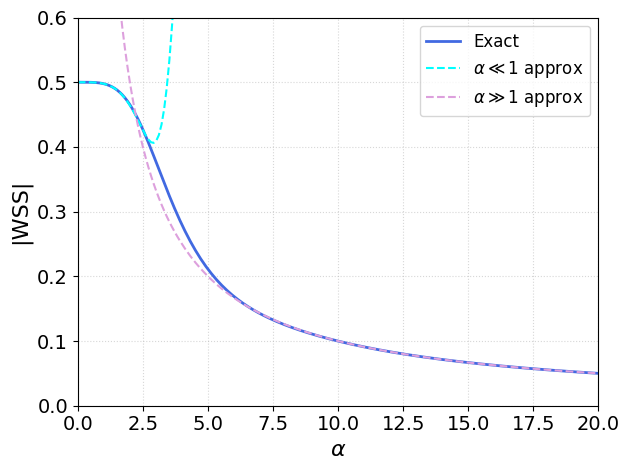

In [ ]:
my_αs = np.linspace(1e-4, 20, 200)

fig, ax = plt.subplots(tight_layout=True)

ax.plot(my_αs, abs(wss2D(my_αs, 0)), color='royalblue', 
        linewidth=2, label='Exact')
ax.plot(my_αs, abs(wss2D_zero(my_αs, 0)), color='cyan', 
        linestyle='dashed', linewidth=1.5, label=r'$\alpha\ll1$ approx')
ax.plot(my_αs, abs(wss2D_inf(my_αs, 0)), color='plum', 
        linestyle='dashed', linewidth=1.5, label=r'$\alpha\gg1$ approx')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('|WSS|')

ax.set_xlim(0, my_αs.max())
ax.set_ylim(0, 0.6)

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();